# Open Loop Sim

## Open-Loop Response of the Multi-Input MFC under a pH Perturbation

Jonathan D. Miller

This notebook reproduces the open-loop (no-control) simulation of the MFC plant over a 4-hour horizon, with a −0.5 pH step perturbation applied at t = 30 min. The identified discrete-time matrices are taken from the firmware v21 system-ID tables.

## 1. Imports and Style

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

COLOR_BASE = '#c0392b'   # red   — open-loop trace
COLOR_SET  = '#555555'   # grey  — setpoint

## 2. System Matrices

Discrete-time state-space model with a 5-second sample period. State vector: `x = [VFA (mg/L), EC (mS/cm), pH]`. Input vector: `u = [urine, apple juice]` in mL/min. Matrices as identified and deployed in firmware v21.

In [2]:
# ── Discrete-time A matrix (5-second sample period) ──────────────────
A_D = np.array([
    [ 0.99930577, -0.00002068, -0.00003493],
    [ 0.00233387,  0.98443635,  0.02453758],
    [-0.00015568,  0.00111512,  0.99805077],
])

# ── Discrete-time B matrix (state change per mL/min per 5-s step) ────
# Columns: [urine, apple juice]
B_D = np.array([
    [ 0.00000000,  1.80650e-3],
    [ 6.84417e-4, -4.73295e-3],
    [ 2.49130e-2, -1.66300e-3],
])

# ── Setpoints ─────────────────────────────────────────────────────────
VFA0, EC0, PH0 = 50.25, 10.0, 7.2
x_sp = np.array([VFA0, EC0, PH0])

# ── Open-loop eigenvalues (sanity check: all must be inside unit circle) ──
eigs_ol = np.linalg.eigvals(A_D)
print('Open-loop A_D eigenvalues:')
for i, z in enumerate(sorted(np.abs(eigs_ol), reverse=True)):
    print(f'  |z{i+1}| = {z:.6f}  stable={z < 1}')

tau_pH_min = -5.0 / (np.log(A_D[2, 2]) * 60.0)
print(f'\npH natural recovery time constant τ ≈ {tau_pH_min:.1f} min')

Open-loop A_D eigenvalues:
  |z1| = 0.999827  stable=True
  |z2| = 0.999305  stable=True
  |z3| = 0.982661  stable=True

pH natural recovery time constant τ ≈ 42.7 min


## 3. Open-Loop Simulation Function

No pump actuation (`u ≡ 0`). The dynamics reduce to

$$x_{k+1} = x_{sp} + A_D (x_k - x_{sp})$$

with an optional pH step perturbation applied at a specified minute.

**Bug note (from the original notebook):** an earlier version initialised `u_current` to `U_BASE` rather than zero in the open-loop branch, which applied a non-zero dose for the first dose interval and produced spurious spikes in all three states at t ≈ 0. This is fixed here by setting `u = 0` throughout.

In [3]:
def run_open_loop(duration_min=240, x0=None,
                  ph_perturbation_min=30, ph_perturb_val=-0.5,
                  dt_sec=5):
    """Propagate the discrete-time model with u ≡ 0.

    Parameters
    ----------
    duration_min : total simulation length in minutes.
    x0 : initial state; defaults to the setpoint `x_sp`.
    ph_perturbation_min : when (min) to apply a pH step; None to skip.
    ph_perturb_val : magnitude of the pH step (e.g. -0.5).
    dt_sec : sample period in seconds (must match A_D discretisation).
    """
    steps_total = int(duration_min * 60 / dt_sec)
    x_true = (x0 if x0 is not None else x_sp).copy().astype(float)
    u_zero = np.zeros(2)

    t_arr = np.zeros(steps_total)
    X_arr = np.zeros((steps_total, 3))

    for k in range(steps_total):
        t_min    = k * dt_sec / 60.0
        t_arr[k] = t_min
        X_arr[k] = x_true.copy()

        # pH step perturbation at the specified minute
        if (ph_perturbation_min is not None
                and abs(t_min - ph_perturbation_min) < dt_sec / 60.0 / 2.0):
            x_true[2] += ph_perturb_val

        # Propagate: u = 0, no disturbance offset
        dx = x_true - x_sp
        x_true = x_sp + A_D @ dx + B_D @ u_zero

        # Physical clipping (wide enough that divergence would be visible)
        x_true[0] = np.clip(x_true[0], 48.0, 56.0)   # VFA  mg/L
        x_true[1] = np.clip(x_true[1],  0.0, 20.0)   # EC   mS/cm
        x_true[2] = np.clip(x_true[2],  3.0, 10.0)   # pH

    return t_arr, X_arr

print('run_open_loop() ready.')

run_open_loop() ready.


## 4. Run the Simulation and Plot the Result

4-hour horizon, −0.5 pH step at t = 30 min, starting exactly at the setpoint `(VFA, EC, pH) = (50.25, 10.0, 7.2)`.

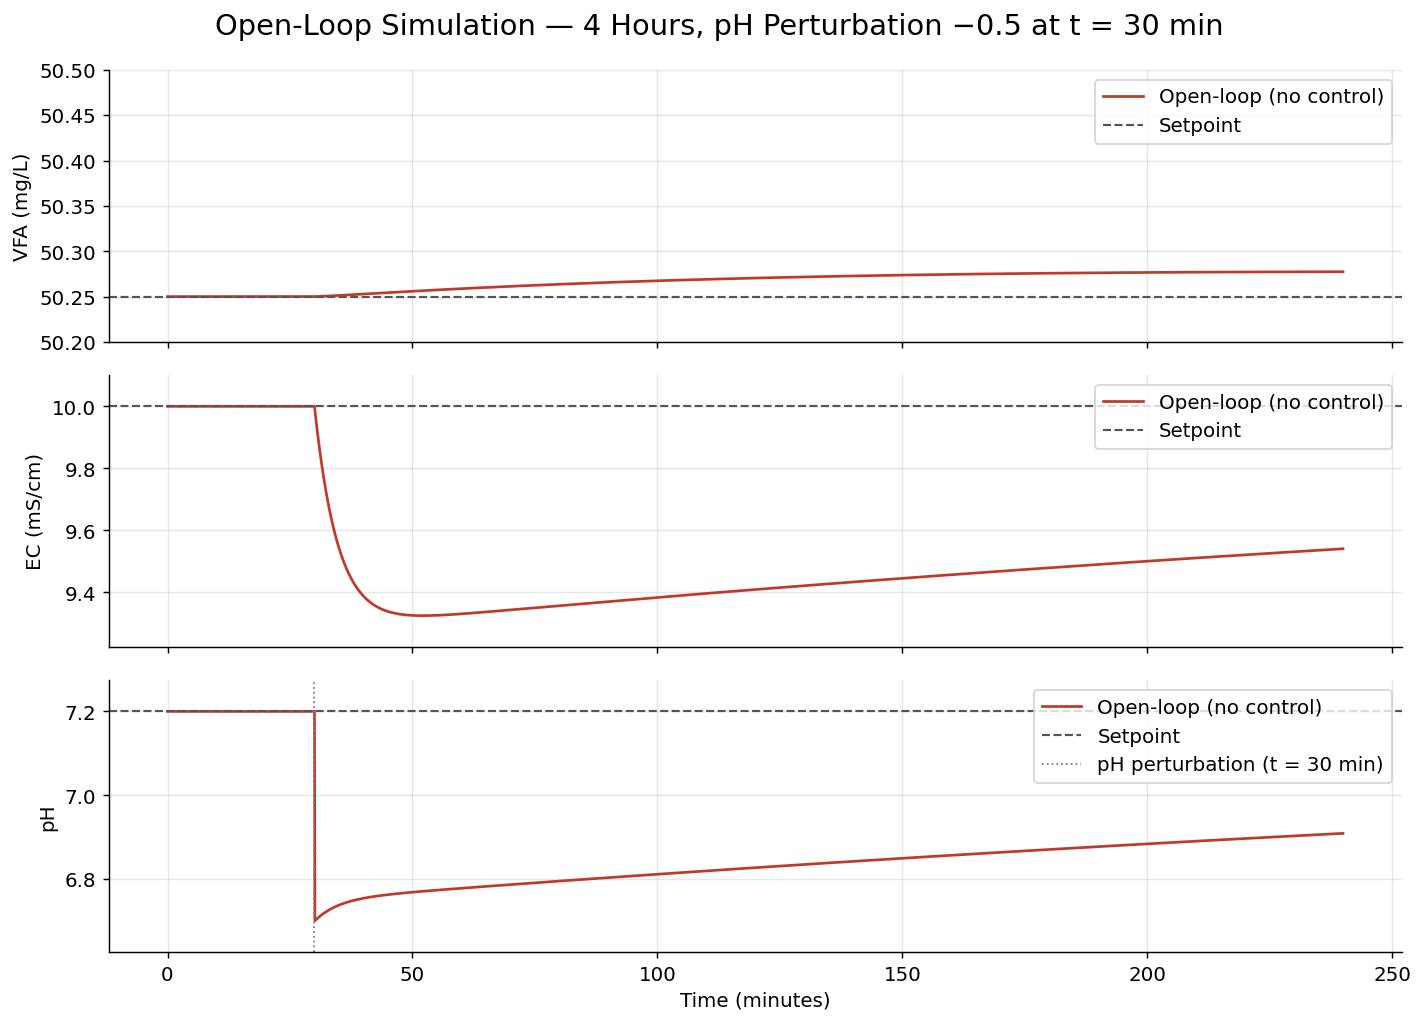


Open-Loop Simulation Summary
  VFA  final : 50.277 mg/L   (setpoint 50.25)
  EC   final : 9.541 mS/cm  (setpoint 10.0)
  pH   final : 6.909         (setpoint 7.2)
  pH offset  : -0.291 units from setpoint after 4 h
  pH nadir   : 6.701 at t = 30.1 min
  EC nadir   : 9.325 at t = 52.1 min


In [4]:
np.random.seed(0)
x0_ol = x_sp.copy()   # start exactly at setpoint

t_ol, X_ol = run_open_loop(
    duration_min=240,
    x0=x0_ol,
    ph_perturbation_min=30,
    ph_perturb_val=-0.5,
)

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
labels = ['VFA (mg/L)', 'EC (mS/cm)', 'pH']
setpts = [VFA0, EC0, PH0]

for i, ax in enumerate(axes):
    ax.plot(t_ol, X_ol[:, i], color=COLOR_BASE, lw=1.5, label='Open-loop (no control)')
    ax.axhline(setpts[i], ls='--', color=COLOR_SET, lw=1.2, label='Setpoint')
    ax.set_ylabel(labels[i])
    lo = min(X_ol[:, i].min(), setpts[i])
    hi = max(X_ol[:, i].max(), setpts[i])
    pad = max((hi - lo) * 0.15, 0.05)
    if i == 0:
        ax.set_ylim(lo - pad, 50.5)
    else:
        ax.set_ylim(lo - pad, hi + pad)
    ax.legend(loc='upper right', fontsize=11)

axes[2].axvline(30, ls=':', color='grey', lw=1, label='pH perturbation (t = 30 min)')
axes[2].legend(loc='upper right', fontsize=11)
axes[-1].set_xlabel('Time (minutes)')
fig.suptitle('Open-Loop Simulation — 4 Hours, pH Perturbation −0.5 at t = 30 min', fontsize=16)
plt.tight_layout()
plt.savefig('open_loop_sim.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nOpen-Loop Simulation Summary')
print(f'  VFA  final : {X_ol[-1,0]:.3f} mg/L   (setpoint {VFA0})')
print(f'  EC   final : {X_ol[-1,1]:.3f} mS/cm  (setpoint {EC0})')
print(f'  pH   final : {X_ol[-1,2]:.3f}         (setpoint {PH0})')
print(f'  pH offset  : {X_ol[-1,2] - PH0:+.3f} units from setpoint after 4 h')
print(f'  pH nadir   : {X_ol[:,2].min():.3f} at t = {t_ol[X_ol[:,2].argmin()]:.1f} min')
print(f'  EC nadir   : {X_ol[:,1].min():.3f} at t = {t_ol[X_ol[:,1].argmin()]:.1f} min')